In [2]:
from topocurve import TopoCurve,SpectralFiltering
import numpy as np
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import os
import matplotlib.pyplot as plt
import earthpy as et
import earthpy.spatial as es
import earthpy.plot as ep
import rasterio as rio
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



# Define the path to the TIFF file
tiff_file = '/Users/ntklema/Library/CloudStorage/OneDrive-FortLewisCollege/Research_Projects/Curvature/ESurf_Paper/Data/Umpqua_10m_2.tif'


# Instantiate TopoCurve object
dem = TopoCurve(tiff_file)


# Instantiate SpectralFiltering object
spectral_filter = SpectralFiltering(tiff_file)


# Apply FFT filtering with a lowpass filter at 190-200
dx, dy, filtered_elevation = spectral_filter.FFT([150, 200], 'lowpass', 0)

# Compute curvature attributes
K = dem.CurveCalc(filtered_elevation, dx, dy, 0)
extent = dem.get_latlon_extent(tiff_file)


/opt/anaconda3/envs/curve/lib/python3.14/site-packages/earthpy/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string
/opt/anaconda3/envs/curve/lib/python3.14/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Text(0, 0.5, 'Latitude (°N)')

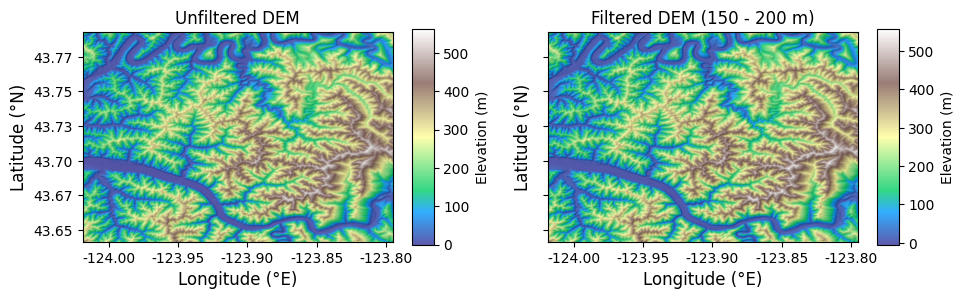

In [4]:
#%% Figure 1
# Compute hillshade for unfiltered baselayer
Z = dem.z_array
azimuth=315 
altitude=50
az = np.deg2rad(azimuth)
alt = np.deg2rad(altitude)
dy, dx = np.gradient(Z)
slope = np.pi/2 - np.arctan(np.sqrt(dx*dx + dy*dy))
aspect = np.arctan2(-dx, dy)
shaded = (np.sin(alt) * np.sin(slope) + np.cos(alt) * np.cos(slope) * np.cos(az - aspect))
hillshade = (shaded - shaded.min()) / (shaded.max() - shaded.min())

fig,ax=plt.subplots(1,2,figsize=(11, 4))
ax[0].imshow(hillshade, cmap="gray", extent=extent, origin="upper")
k=ax[0].imshow(Z, cmap="terrain", alpha=0.8, extent=extent, origin="upper")
ax[0].set_xlabel("Longitude (°E)",fontsize=12)
ax[0].set_ylabel("Latitude (°N)",fontsize=12)
ax[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax[0].set_title('Unfiltered DEM')
fig.colorbar(k, ax=ax[0],label = 'Elevation (m)',shrink=0.7,aspect=10)
#ax[0].text(-107.865,37.64,'A',fontsize=15,fontweight='bold')

# Compute hillshade for filtered baselayer
Z = filtered_elevation
azimuth=315 
altitude=50
az = np.deg2rad(azimuth)
alt = np.deg2rad(altitude)
dy, dx = np.gradient(Z)
slope = np.pi/2 - np.arctan(np.sqrt(dx*dx + dy*dy))
aspect = np.arctan2(-dx, dy)
shaded = (np.sin(alt) * np.sin(slope) + np.cos(alt) * np.cos(slope) * np.cos(az - aspect))
hillshade = (shaded - shaded.min()) / (shaded.max() - shaded.min())

ax[1].imshow(hillshade, cmap="gray", extent=extent, origin="upper")
k=ax[1].imshow(Z, cmap="terrain", alpha=0.8, extent=extent, origin="upper")
ax[1].set_xlabel("Longitude (°E)",fontsize=12)
ax[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# ax[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax[1].set_yticklabels([])

ax[1].set_title('Filtered DEM (150 - 200 m)')
fig.colorbar(k, ax=ax[1],label = 'Elevation (m)',shrink=0.7,aspect=10)
#ax[1].text(1,1,'B',fontsize=15,fontweight='bold')
ax[1].set_ylabel("Latitude (°N)",fontsize=12)
